# CIFAR-10 — Plain CNN

A custom CNN with 4 convolutional layers, BatchNorm, MaxPool, Dropout,
and Global Average Pooling. No residual connections — this serves as
the baseline to compare against the ResNet variants.

## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from utils.dataset import get_cifar10_dataloaders, CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

In [3]:
batch_size = 256

trainloader, valloader, testloader = get_cifar10_dataloaders(
    batch_size=batch_size, num_workers=4, img_size=32,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

100.0%
C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 157 | Val batches: 40 | Test batches: 40


## Visualize Sample Batch

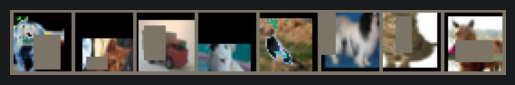

dog   cat   truck dog   bird  dog   cat   horse


In [4]:
show_sample_batch(trainloader, CLASSES)

## Model Definition

Plain CNN with BatchNorm, Global Average Pooling, and Dropout.
No skip connections — purely feed-forward.

In [5]:
class PlainCNN(nn.Module):
    def __init__(self):
        super(PlainCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 10)
        self.do = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        x = self.do(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

## Initialize Model & Print Summary

In [6]:
model = PlainCNN().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

PlainCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (do): Dropout(p=0.5, inplace=False)
)

Total parameters: 9

## Training Configuration

In [7]:
criterion = nn.CrossEntropyLoss()
epochs = 80
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4,
)

scaler = torch.amp.GradScaler('cuda')

checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path='../../checkpoint/plain_cnn_latest.pth',
    best_model_path='../../checkpoint/plain_cnn_best.pth',
    mode='max',
    verbose=True,
)

## Training Loop

In [8]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
)

[ModelCheckpoint] New best (max): 37.2800 — saved to ..\checkpoint\plain_cnn_best.pth
Epoch [ 1/80]  Train Loss: 2.0859  Val Loss: 1.6537  Val Acc: 37.28%  LR: 0.004411  Time: 16.85s
[ModelCheckpoint] New best (max): 43.1900 — saved to ..\checkpoint\plain_cnn_best.pth
Epoch [ 2/80]  Train Loss: 1.8398  Val Loss: 1.5279  Val Acc: 43.19%  LR: 0.005636  Time: 4.87s
Epoch [ 3/80]  Train Loss: 1.7063  Val Loss: 1.5956  Val Acc: 42.66%  LR: 0.007656  Time: 4.57s
[ModelCheckpoint] New best (max): 45.0200 — saved to ..\checkpoint\plain_cnn_best.pth
Epoch [ 4/80]  Train Loss: 1.6297  Val Loss: 1.4994  Val Acc: 45.02%  LR: 0.010434  Time: 3.96s
[ModelCheckpoint] New best (max): 46.6800 — saved to ..\checkpoint\plain_cnn_best.pth
Epoch [ 5/80]  Train Loss: 1.5334  Val Loss: 1.4972  Val Acc: 46.68%  LR: 0.013924  Time: 4.07s
[ModelCheckpoint] New best (max): 53.2900 — saved to ..\checkpoint\plain_cnn_best.pth
Epoch [ 6/80]  Train Loss: 1.4812  Val Loss: 1.2992  Val Acc: 53.29%  LR: 0.018066  Time:

## Restore Best Weights & Test Evaluation

In [9]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')

[ModelCheckpoint] Restored best weights from ..\checkpoint\plain_cnn_best.pth (score=90.2400)

Overall Test Accuracy: 89.82%

  plane: 92.1%
  car  : 95.5%
  bird : 84.6%
  cat  : 75.1%
  deer : 90.9%
  dog  : 85.5%
  frog : 93.3%
  horse: 92.4%
  ship : 93.8%
  truck: 95.0%


## Training Curves

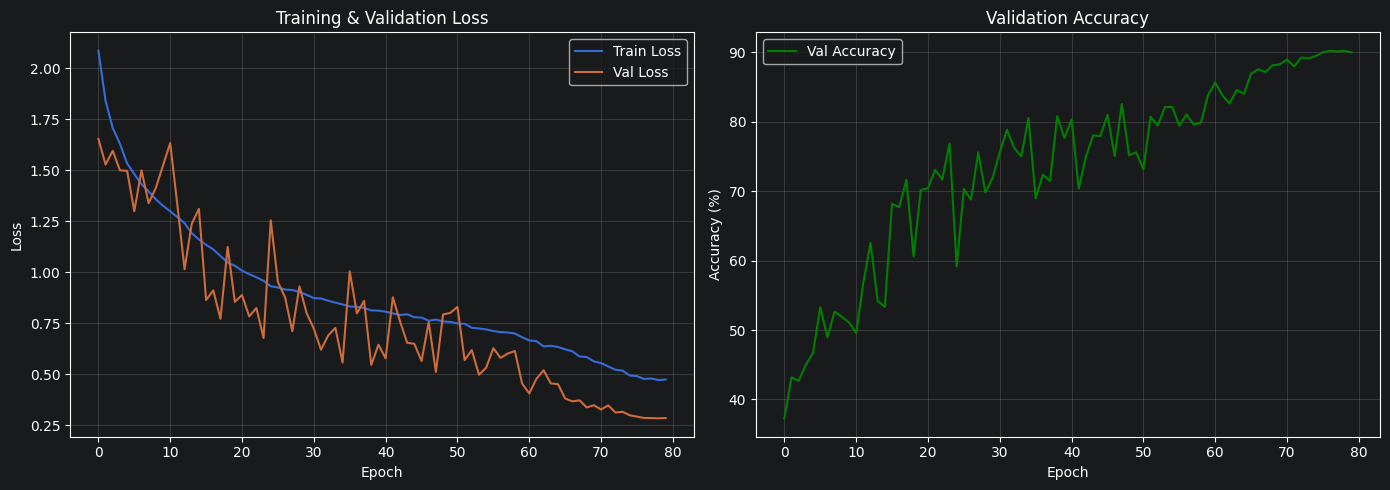

In [10]:
plot_training_curves(train_losses, val_losses, val_accuracies)